# Attempt on 10s

Directories

In [1]:
from pathlib import Path

# Source folder: ~/Documents/vid_10s_wdark_faulty_dataset/
base_path = Path.home() / "Documents" / "vid_10s_wdark_faulty_dataset" / "raw_vids"

# Destination folders
train_path = Path.home() / "Documents" /  "vid_10s_wdark_faulty_dataset" / "split" / "train"
val_path = Path.home() / "Documents" /  "vid_10s_wdark_faulty_dataset" / "split" / "val"

# Class names = folder names
classes = ["starlight", "wave", "spectrum_cycling", "faulty"]

In [2]:
#run to allow mixed, resets every restarted kernel, can be reverted to default with "mixed_precision.set_global_policy('float32')" 

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

c:\Users\YinYu\anaconda3\envs\tf_clean\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4090 Laptop GPU, compute capability 8.9


Splitting directories

In [4]:
print( Path.home())

C:\Users\YinYu


In [6]:
from pathlib import Path
import shutil
import random
import os

# Source folder: ~/Documents/vid_10s_wdark_faulty_dataset/
base_path = Path.home() / "Documents" / "vid_10s_wdark_faulty_dataset" / "raw_vids"

# Destination folders
train_path = Path.home() / "Documents" /  "vid_10s_wdark_faulty_dataset" / "split" / "train"
val_path = Path.home() / "Documents" /  "vid_10s_wdark_faulty_dataset" / "split" / "val"

# Class names = folder names
classes = ["starlight", "wave", "spectrum_cycling", "faulty"]

# Train/Val ratio
train_ratio = 0.8

# Create output directories
for split_path in [train_path, val_path]:
    for cls in classes:
        os.makedirs(split_path / cls, exist_ok=True)

# Split and copy files
for cls in classes:
    class_dir = base_path / cls
    video_files = list(class_dir.glob("*.mp4"))
    random.shuffle(video_files)

    train_count = int(len(video_files) * train_ratio)
    train_videos = video_files[:train_count]
    val_videos = video_files[train_count:]

    for vid in train_videos:
        shutil.copy(vid, train_path / cls / vid.name)
    for vid in val_videos:
        shutil.copy(vid, val_path / cls / vid.name)

Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional
import tensorflow as tf

def build_cnn_lstm(input_shape=(300, 112, 112, 3), num_classes=4):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2), metrics=['accuracy'])
    return model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional
import tensorflow as tf

def build_cnn_lstm2(input_shape=(300, 112, 112, 3), num_classes=4):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64, return_sequences=True)),  # Intermediate temporal outputs
        Bidirectional(LSTM(64)),                         # Final temporal summary
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2), metrics=['accuracy'])
    return model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, AveragePooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional, AveragePooling2D
import tensorflow as tf

def build_cnn_lstm3(input_shape=(300, 112, 112, 3), num_classes=4):
    model = Sequential([
        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(64, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model



In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("NumPy version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TF version: 2.10.1
NumPy version: 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, AveragePooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional, AveragePooling2D
import tensorflow as tf

img_size = 160

def build_cnn_lstm4(input_shape=(300, img_size, img_size, 3), num_classes=4):
    model = Sequential([
        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(64, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model



In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, AveragePooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional, AveragePooling2D
import tensorflow as tf

img_size = 160

def build_cnn_lstm5(input_shape=(300, img_size, img_size, 3), num_classes=4):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),
        TimeDistributed(Dropout(0.3)),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(AveragePooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax', dtype='float32')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model



Label

In [8]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

labels = ["starlight", "wave", "spectrum_cycling", "faulty"]
le = LabelEncoder()
y_encoded = le.fit_transform(labels)
y_cat = to_categorical(y_encoded)

Augmentation

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from pathlib import Path
import albumentations as A

img_size = 160

class OnTheFlyVideoGenerator(Sequence):
    def __init__(self, data_dir, class_names, frame_count=300, target_size=(img_size, img_size), batch_size=4, shuffle=True, augment=False):
        self.data_dir = Path(data_dir)
        self.class_names = class_names
        self.frame_count = frame_count
        self.target_size = target_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.video_paths = []
        self.labels = []
        self.augment = augment
        # self.frame_aug = A.Compose([
        #     A.RandomBrightnessContrast(p=0.5),
        #     A.HorizontalFlip(p=0.5),
        #     A.Rotate(limit=10, p=0.3),
        #     A.HueSaturationValue(p=0.4),
        # ])
        self.frame_aug = A.Compose([
            # Geometric/motion
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, p=0.3),

            # One lighting/color tweak per frame, most of the time
            A.OneOf([
                A.RandomBrightnessContrast(
                brightness_limit=(-0.5, 0.5),
                contrast_limit=(0.2, 0.8), p=1
                ),
                A.RandomGamma(gamma_limit=(30, 120), p=1),
                A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=1),
                A.HueSaturationValue(p=1),
            ], p=0.8),
        ])

        for idx, class_name in enumerate(class_names):
            for video_file in (self.data_dir / class_name).glob("*.mp4"):
                self.video_paths.append(video_file)
                self.labels.append(idx)

        self.indices = np.arange(len(self.video_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_x, batch_y = [], []
        for i in batch_indices:
            video_path = self.video_paths[i]
            frames = self.load_video_frames(video_path)
            batch_x.append(frames)
            batch_y.append(self.labels[i])
        return np.array(batch_x), tf.keras.utils.to_categorical(batch_y, num_classes=len(self.class_names))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def load_video_frames(self, video_path):
        cap = cv2.VideoCapture(str(video_path))
        frames = []

        # # sharpening kernel (unsharp mask)
        # sharpen_kernel = np.array([
        #     [ 0, -1,  0],
        #     [-1,  5, -1],
        #     [ 0, -1,  0]
        # ], dtype=np.float32)

        while len(frames) < self.frame_count and cap.isOpened():
            ret, frame = cap.read()
            if not ret or frame is None:
                break

            # 1) high-quality resize
            frame = cv2.resize(frame, self.target_size, interpolation=cv2.INTER_LANCZOS4)

            # # 2) sharpen
            # frame = cv2.filter2D(frame, -1, sharpen_kernel)

            if self.augment and isinstance(frame, np.ndarray):
                frame = self.frame_aug(image=frame)["image"]
            frame = frame.astype(np.float32)
            frame = frame / 255.0
            frames.append(frame)
        cap.release()
        if len(frames) < self.frame_count:
            pad_frame = np.zeros((self.target_size[1], self.target_size[0], 3), dtype=np.float32)
            frames += [pad_frame] * (self.frame_count - len(frames))
        elif len(frames) > self.frame_count:
            frames = frames[:self.frame_count]  # Trim if needed
        return np.array(frames, dtype=np.float32)

C:\Users\Yin Yu\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Yin Yu\AppData\Roaming\Python\Python310\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
class_names = ["starlight", "wave", "spectrum_cycling", "faulty"]

train_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_10s_wdark_faulty_dataset" / "split" / "train",
    class_names=class_names,
    augment=True
)

val_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_10s_wdark_faulty_dataset" / "split" / "val",
    class_names=class_names,
    augment=False
)

Train

In [ ]:
import tensorflow as tf
from sklearn.utils import class_weight
import os
import json
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# model = build_cnn_lstm()
# model = build_conv_lstm()
# model = build_cnn_lstm2()
# model = build_cnn_lstm3()
# model = build_cnn_lstm4()
model = build_cnn_lstm5()


base_path = Path.cwd().resolve().parents[1]
checkpoint_path = base_path / "models" / "checkpoints" / "video_trydarkfaulty_model.h5"
final_model_path = base_path / "models" / "video_recognition" / "video_darkfaulty_model.h5"
metrics_path = base_path / "metrics" / "video_recognition"
metrics_path.mkdir(parents=True, exist_ok=True) 

checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Compute class weights from train_gen
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.labels),
    y=train_gen.labels
)
class_weights_dict = dict(enumerate(class_weights))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping]
)

# === Evaluate Best Model ===
best_refined_model = tf.keras.models.load_model(checkpoint_path)
val_loss, val_accuracy = best_refined_model.evaluate(val_gen)
print(f"Best Validation Loss: {val_loss:.4f}")
print(f"Best Validation Accuracy: {val_accuracy:.4f}")

# === Save Final Model and Metrics ===
best_refined_model.save(final_model_path)
with open(metrics_path / "video_darkfaulty_model.json", "w") as f:
    json.dump(history.history, f)

Epoch 1/15
42/42 [==============================] - 503s 12s/step - loss: 1.1464 - accuracy: 0.2738 - val_loss: 1.0323 - val_accuracy: 0.3333
Epoch 2/15
42/42 [==============================] - 405s 10s/step - loss: 0.8409 - accuracy: 0.5833 - val_loss: 0.5798 - val_accuracy: 0.9048
Epoch 3/15
42/42 [==============================] - 356s 9s/step - loss: 0.6393 - accuracy: 0.7857 - val_loss: 0.5505 - val_accuracy: 1.0000
Epoch 4/15
42/42 [==============================] - 361s 9s/step - loss: 0.6105 - accuracy: 0.8214 - val_loss: 0.4679 - val_accuracy: 0.9524
Epoch 5/15
20/42 [=============>................] - ETA: 2:32 - loss: 0.5561 - accuracy: 0.8750

Evaluation

In [ ]:
test_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_10s_wdark_dataset" / "split" / "test",
    class_names=["starlight", "wave", "spectrum_cycling", "faulty"],
    shuffle=False  # disable shuffling so predictions align with files
)

In [ ]:
from tensorflow.keras.models import load_model

all_preds = []
all_labels = []

base_path = Path.cwd().resolve().parents[1]
model_path = base_path / "models" / "video_recognition" / "video_darkfaulty_model.h5"
model = load_model(model_path)

for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]
    batch_preds = model.predict(x_batch)
    all_preds.extend(batch_preds.argmax(axis=1))
    all_labels.extend(y_batch.argmax(axis=1))

1/1 [==============================] - 0s 196ms/step


In [41]:
from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("\nDetailed Report:\n", classification_report(all_labels, all_preds, target_names=test_gen.class_names))


Test Accuracy: 1.0

Detailed Report:
                   precision    recall  f1-score   support

       starlight       1.00      1.00      1.00         5
            wave       1.00      1.00      1.00         5
spectrum_cycling       1.00      1.00      1.00         5

        accuracy                           1.00        15
       macro avg       1.00      1.00      1.00        15
    weighted avg       1.00      1.00      1.00        15



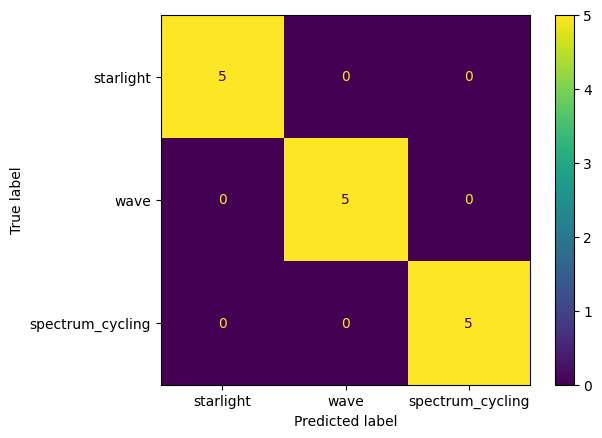

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=test_gen.class_names).plot()

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.sysconfig.get_build_info()["cuda_version"])
print("Built with cuDNN:", tf.sysconfig.get_build_info()["cudnn_version"])

TensorFlow version: 2.10.1
Built with CUDA: 64_112
Built with cuDNN: 64_8


Inference

In [7]:
print(test_gen.class_names)

['starlight', 'wave', 'spectrum_cycling']


Input shape: (300, 160, 160, 3)
1/1 [==============================] - 1s 1s/step
recording.mp4 → [0.04208038 0.02292766 0.934992  ]
Class Probabilities:
starlight: 0.0421
wave: 0.0229
spectrum_cycling: 0.9350
Predicted Class: spectrum_cycling


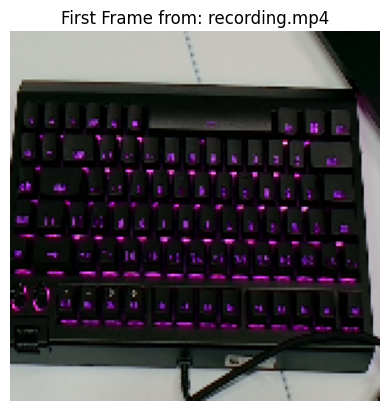

In [ ]:
import numpy as np
from pathlib import Path
from tensorflow.keras.models import load_model

base_path = Path.cwd().resolve().parents[1]
model_path = base_path / "models" / "video_recognition" / "video_darkfaulty_model.h5"
model = load_model(model_path)

# path = base_path / "Robot" / "pictures" / "testt_31.mp4"
# path = base_path / "Robot" / "pictures" / "MicrosoftTeams-video (9).mp4"
# path = base_path / "Robot" / "pictures" / "test_27.mp4"
path = base_path / "Robot" / "pictures" / "recording.mp4"

# Load and preprocess frame
frames = test_gen.load_video_frames(path)
print("Input shape:", frames.shape)  # Debug

# Expand dims for batch
input_tensor = np.expand_dims(frames, axis=0)  # (1, frames, img_size, img_size, 3)

# Predict
pred_probs = model.predict(input_tensor)[0]

# Output
print(f"{path.name} → {pred_probs}")
print("Class Probabilities:")
for i, prob in enumerate(pred_probs):
    print(f"{test_gen.class_names[i]}: {prob:.4f}")

print(f"Predicted Class: {test_gen.class_names[np.argmax(pred_probs)]}")

import matplotlib.pyplot as plt

first_frame = frames[0]  # Shape: (img_size, img_size, 3)

plt.imshow(first_frame)
plt.title(f"First Frame from: {path.name}")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# === Setup Paths ===
base_path = Path.cwd().resolve().parents[1]
video_dir = base_path / "Robot" / "pictures"
model_path = base_path / "models" / "video_recognition" / "video_darkfaulty_model.h5"

# === Load Model ===
model = load_model(model_path)

# === Collect Results ===
results = []

# === Loop through all .mp4 videos ===
for path in sorted(video_dir.glob("*.mp4")):
    try:
        # Load and preprocess frames
        frames = test_gen.load_video_frames(path)
        input_tensor = np.expand_dims(frames, axis=0)

        # Predict
        pred_probs = model.predict(input_tensor, verbose=0)[0]
        predicted_class = test_gen.class_names[np.argmax(pred_probs)]

        # Print result
        print(f"{path.name} → {predicted_class}")
        for i, prob in enumerate(pred_probs):
            print(f"  {test_gen.class_names[i]}: {prob:.4f}")

        # # Store in results list
        # results.append({
        #     "filename": path.name,
        #     "predicted_class": predicted_class,
        #     **{f"{test_gen.class_names[i]}_prob": float(prob) for i, prob in enumerate(pred_probs)}
        # })

    except Exception as e:
        print(f"Error processing {path.name}: {e}")

MicrosoftTeams-video (1).mp4 → spectrum_cycling
  starlight: 0.0428
  wave: 0.0190
  spectrum_cycling: 0.9382
MicrosoftTeams-video (2).mp4 → spectrum_cycling
  starlight: 0.0499
  wave: 0.0594
  spectrum_cycling: 0.8907
MicrosoftTeams-video (3).mp4 → wave
  starlight: 0.0946
  wave: 0.7299
  spectrum_cycling: 0.1755
MicrosoftTeams-video (4).mp4 → wave
  starlight: 0.0324
  wave: 0.9348
  spectrum_cycling: 0.0328
MicrosoftTeams-video (5).mp4 → starlight
  starlight: 0.9516
  wave: 0.0221
  spectrum_cycling: 0.0263
MicrosoftTeams-video (6).mp4 → starlight
  starlight: 0.9510
  wave: 0.0223
  spectrum_cycling: 0.0267
MicrosoftTeams-video (7).mp4 → starlight
  starlight: 0.9463
  wave: 0.0231
  spectrum_cycling: 0.0306
MicrosoftTeams-video (8).mp4 → wave
  starlight: 0.0670
  wave: 0.8549
  spectrum_cycling: 0.0781
MicrosoftTeams-video (9).mp4 → spectrum_cycling
  starlight: 0.0348
  wave: 0.0336
  spectrum_cycling: 0.9316
MicrosoftTeams-video.mp4 → starlight
  starlight: 0.9508
  wave: 0.

In [ ]:
import matplotlib.pyplot as plt

# Get one batch
batch_x, batch_y = train_gen[0]

# Shape: (batch_size, frame_count, H, W, 3)
print("Batch shape:", batch_x.shape)

# Extract first frame of first video
first_video = batch_x[0]         # (frame_count, H, W, 3)
first_frame = first_video[0]     # (H, W, 3)

# Display
plt.imshow(first_frame)
plt.title("First frame of first video")
plt.axis("off")
plt.show()